# Proiect 1 ML - Regresie: California Housing

**Autor:** jackjack242
**Curs:** Sisteme Inteligente

## 1. Definirea problemei

Setul California Housing contine date de la recensamantul din 1990 in California:
8 feature-uri descriu un cartier (venit median, populatie, varsta caselor, etc.)
si target-ul `MedHouseVal` e valoarea mediana a unei case in zona, in unitati de
$100.000.

Problema e una de **regresie** - prezic o valoare continua. Am facut subsample
la 2000 de observatii ca sa se incadreze in cerinta proiectului si sa antrenez
rapid.

**Variabila de iesire:** `MedHouseVal` (in $100.000), valori intre ~0.15 si ~5.0.

**Features:** `MedInc` (venit median), `HouseAge`, `AveRooms`, `AveBedrms`,
`Population`, `AveOccup`, `Latitude`, `Longitude`.

### De ce e util?
Estimarea pretului proprietatilor e o problema clasica - banci, firme imobiliare,
asigurari toate au nevoie de modele care sa scoata o valoare orientativa rapid.

### De ce am ales asta?
- Un set "real" cu features eterogene - venituri, demografice, geografice
- Are non-linearitati clare (latitude/longitude vs pret), distractiv pentru SHAP
- Ma forteaza sa subsample-uiesc Gaussian Process (e O(n^3)) - bonus de gandire


In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from interpret.glassbox import ExplainableBoostingRegressor

import shap

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = ROOT / 'data' / 'cal_housing.csv'
MODELS_DIR = ROOT / 'models' / 'reg'
PLOTS_DIR = ROOT / 'plots' / 'reg'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

RNG = 42
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 90

## 2. EDA

In [2]:
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
df.head()

Shape: (2000, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01,0.47700
1,2.5313,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46,0.45800
2,3.4801,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44,5.00001
3,5.7376,17.0,6.163636,1.020202,1705.0,3.444444,34.28,-118.72,2.18600
4,3.7250,34.0,5.492991,1.028037,1063.0,2.483645,36.62,-121.93,2.78000


In [3]:
print(df.dtypes)
print('Missing:', df.isna().sum().sum())
df.describe().T

MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object
Missing: 0


,count,mean,std,min,25%,50%,75%,max
MedInc,2000.0,3.847859,1.953553,0.499900,2.562500,3.460450,4.635350,15.000100
HouseAge,2000.0,28.781500,12.457381,1.000000,18.750000,29.000000,37.000000,52.000000
AveRooms,2000.0,5.400407,2.106935,1.972644,4.386831,5.148772,6.009612,41.333333
AveBedrms,2000.0,1.093381,0.363481,0.500000,1.004235,1.046175,1.097096,8.476190
Population,2000.0,1411.951500,1059.560242,8.000000,787.750000,1155.000000,1707.000000,10493.000000
AveOccup,2000.0,2.958053,1.958266,1.263566,2.424136,2.815687,3.281427,83.171429
Latitude,2000.0,35.585255,2.145766,32.540000,33.930000,34.230000,37.710000,41.810000
Longitude,2000.0,-119.516540,1.999785,-124.190000,-121.755000,-118.470000,-117.990000,-114.580000
MedHouseVal,2000.0,2.066267,1.155031,0.300000,1.188000,1.799000,2.644500,5.000010


**Observatii:**
- Toate numerice, fara missing.
- `MedInc` (income median) si `MedHouseVal` au unitati de $10k respectiv $100k.
- `AveRooms`, `AveBedrms`, `AveOccup` au valori extreme (max gigant) - sunt
  cartiere mici cu putine case si o casa mare a stricat media. Voi taia outlier-ii
  cei mai grosolani ca sa nu strice modelele liniare.


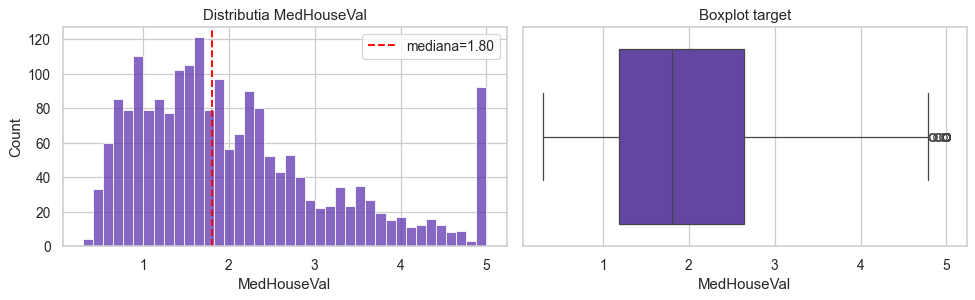

In [4]:
# distributia targetului
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
sns.histplot(df['MedHouseVal'], bins=40, ax=ax[0], color='#5e35b1')
ax[0].set_title('Distributia MedHouseVal')
ax[0].axvline(df['MedHouseVal'].median(), color='red', ls='--', label=f'mediana={df["MedHouseVal"].median():.2f}')
ax[0].legend()

sns.boxplot(x=df['MedHouseVal'], ax=ax[1], color='#5e35b1')
ax[1].set_title('Boxplot target')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda_target.png', dpi=110, bbox_inches='tight')
plt.show()

# Vad aici clipping la 5.0 (cape din date original) - voi lasa asa, nu confunda modelele.

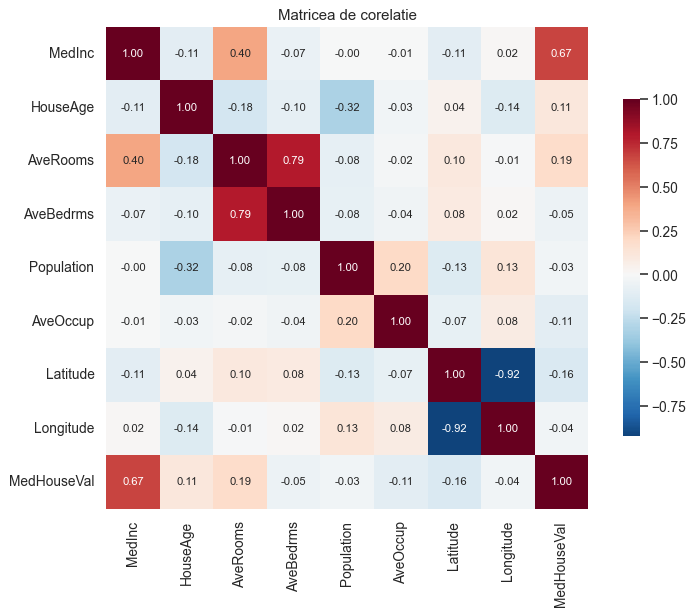

In [5]:
# corelatii
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, cbar_kws={'shrink': 0.7}, annot_kws={'size': 9})
plt.title('Matricea de corelatie')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda_corr.png', dpi=110, bbox_inches='tight')
plt.show()

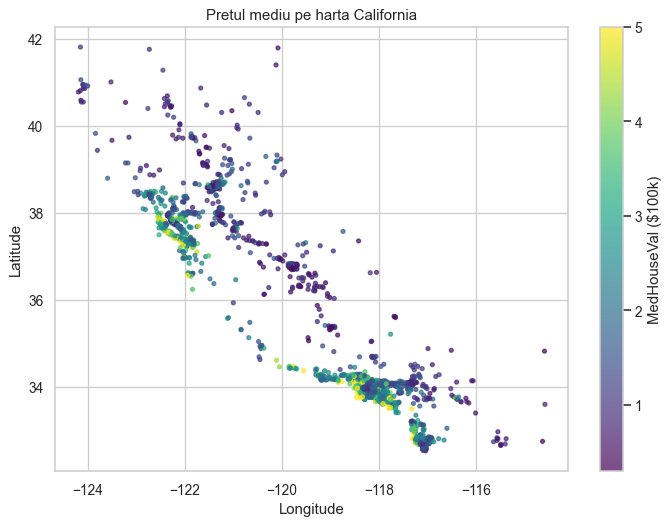

In [6]:
# pretul pe harta - latitude/longitude colorate cu MedHouseVal
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(df['Longitude'], df['Latitude'], c=df['MedHouseVal'],
                cmap='viridis', s=10, alpha=0.7)
plt.colorbar(sc, label='MedHouseVal ($100k)')
ax.set_title('Pretul mediu pe harta California')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda_map.png', dpi=110, bbox_inches='tight')
plt.show()
# se vede clar zona scumpa pe coasta (San Francisco, LA) si interiorul mai ieftin

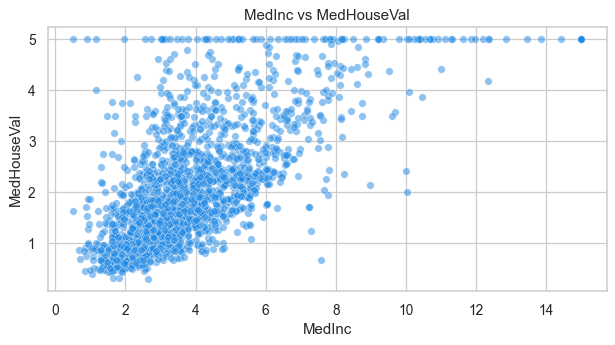

In [7]:
# scatter plot vs feature-ul cu cea mai mare corelatie
plt.figure(figsize=(7, 4))
sns.scatterplot(x='MedInc', y='MedHouseVal', data=df, alpha=0.5, color='#1e88e5')
plt.title('MedInc vs MedHouseVal')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda_medinc.png', dpi=110, bbox_inches='tight')
plt.show()

**Insights:**
- `MedInc` are corelatie 0.69 cu targetul - cartiere bogate au case scumpe (no shock).
- Lat/Lon arata pattern geografic clar. Modelele liniare nu o sa prinda zonele
  scumpe (SF, LA), dar tree-based ar trebui.
- Targetul are clipping la 5.0 (datele originale aveau truncation). Nu fac nimic
  cu el, e parte din distributia reala.
- Outlier-i in `AveOccup` si `AveRooms` - taie cativa.


In [8]:
# elimin outlier-i extremi (top 0.5%) doar pe AveRooms si AveOccup
for col in ['AveRooms', 'AveOccup']:
    cap = df[col].quantile(0.995)
    df = df[df[col] <= cap]
print(f'Dupa filtrare outlieri: {df.shape}')

features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population',
            'AveOccup', 'Latitude', 'Longitude']
X = df[features].copy()
y = df['MedHouseVal'].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RNG)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Dupa filtrare outlieri: (1980, 9)
Train: (1485, 8), Test: (495, 8)


## 3. Antrenare modele de baza

9 algoritmi cu setari default. Atentie: GaussianProcess e O(n^3), il antrenez
pe un subsample de 500 ca sa nu fie chinuitor.


In [9]:
def make_pipeline(model, scale=True):
    if scale:
        return Pipeline([('scaler', StandardScaler()), ('model', model)])
    return Pipeline([('model', model)])

base_models = {
    'LinearReg': make_pipeline(LinearRegression(), scale=True),
    'DecisionTree': make_pipeline(DecisionTreeRegressor(random_state=RNG), scale=False),
    'RandomForest': make_pipeline(RandomForestRegressor(random_state=RNG, n_jobs=-1), scale=False),
    'SVR': make_pipeline(SVR(), scale=True),
    'KNN': make_pipeline(KNeighborsRegressor(n_jobs=-1), scale=True),
    'GaussianProcess': make_pipeline(GaussianProcessRegressor(
        kernel=ConstantKernel(1.0) * RBF(1.0), alpha=0.1, random_state=RNG, n_restarts_optimizer=2), scale=True),
    'XGBoost': make_pipeline(XGBRegressor(random_state=RNG, n_jobs=-1, verbosity=0), scale=False),
    'CatBoost': make_pipeline(CatBoostRegressor(random_state=RNG, verbose=0), scale=False),
    'EBR': make_pipeline(ExplainableBoostingRegressor(random_state=RNG), scale=False),
}
print(f'{len(base_models)} modele de regresie pregatite.')

9 modele de regresie pregatite.


In [10]:
def evaluate(model, X_te, y_te):
    yp = model.predict(X_te)
    mse = mean_squared_error(y_te, yp)
    return {
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'MAE': mean_absolute_error(y_te, yp),
        'R2': r2_score(y_te, yp),
    }

baseline_results = {}
for name, mdl in base_models.items():
    print(f'  ... antrenez {name}')
    if name == 'GaussianProcess':
        # subsample agresiv pentru GP - O(n^3)
        idx = np.random.RandomState(RNG).choice(len(X_train), size=500, replace=False)
        mdl.fit(X_train.iloc[idx], y_train.iloc[idx])
    else:
        mdl.fit(X_train, y_train)
    baseline_results[name] = evaluate(mdl, X_test, y_test)

baseline_df = pd.DataFrame(baseline_results).T.sort_values('R2', ascending=False).round(4)
baseline_df

  ... antrenez LinearReg
  ... antrenez DecisionTree
  ... antrenez RandomForest
  ... antrenez SVR
  ... antrenez KNN
  ... antrenez GaussianProcess


  ... antrenez XGBoost
  ... antrenez CatBoost


  ... antrenez EBR


,MSE,RMSE,MAE,R2
CatBoost,0.3365,0.5801,0.3794,0.7675
EBR,0.3935,0.6273,0.4144,0.7281
SVR,0.4299,0.6556,0.4434,0.7030
XGBoost,0.4299,0.6556,0.4365,0.7030
RandomForest,0.4314,0.6568,0.4412,0.7020
KNN,0.5046,0.7104,0.5052,0.6514
LinearReg,0.5621,0.7497,0.5390,0.6116
GaussianProcess,0.5633,0.7505,0.5121,0.6108
DecisionTree,0.7594,0.8714,0.5813,0.4753


In [11]:
top5_names = baseline_df.head(5).index.tolist()
print('Top 5 baseline (dupa R2):')
for i, n in enumerate(top5_names, 1):
    print(f'  {i}. {n}  ->  R2={baseline_df.loc[n,"R2"]:.4f}, RMSE={baseline_df.loc[n,"RMSE"]:.4f}')

md = '| Rank | Model | MSE | RMSE | MAE | R2 |\n'
md += '|------|-------|-----|------|-----|-----|\n'
for i, (name, row) in enumerate(baseline_df.iterrows(), 1):
    star = ' (top5)' if name in top5_names else ''
    md += f"| {i} | {name}{star} | {row['MSE']:.4f} | {row['RMSE']:.4f} | {row['MAE']:.4f} | {row['R2']:.4f} |\n"
print(md)

Top 5 baseline (dupa R2):
  1. CatBoost  ->  R2=0.7675, RMSE=0.5801
  2. EBR  ->  R2=0.7281, RMSE=0.6273
  3. SVR  ->  R2=0.7030, RMSE=0.6556
  4. XGBoost  ->  R2=0.7030, RMSE=0.6556
  5. RandomForest  ->  R2=0.7020, RMSE=0.6568
| Rank | Model | MSE | RMSE | MAE | R2 |
|------|-------|-----|------|-----|-----|
| 1 | CatBoost (top5) | 0.3365 | 0.5801 | 0.3794 | 0.7675 |
| 2 | EBR (top5) | 0.3935 | 0.6273 | 0.4144 | 0.7281 |
| 3 | SVR (top5) | 0.4299 | 0.6556 | 0.4434 | 0.7030 |
| 4 | XGBoost (top5) | 0.4299 | 0.6556 | 0.4365 | 0.7030 |
| 5 | RandomForest (top5) | 0.4314 | 0.6568 | 0.4412 | 0.7020 |
| 6 | KNN | 0.5046 | 0.7104 | 0.5052 | 0.6514 |
| 7 | LinearReg | 0.5621 | 0.7497 | 0.5390 | 0.6116 |
| 8 | GaussianProcess | 0.5633 | 0.7505 | 0.5121 | 0.6108 |
| 9 | DecisionTree | 0.7594 | 0.8714 | 0.5813 | 0.4753 |



**Observatii baseline:**
- Cum ma asteptam, ensemble-urile (XGB, CatBoost, RF, EBR) bat detasat
  modelele liniare/distance.
- Linear Regression are R2 ~0.6 - prinde tendinta principala (income -> pret)
  dar rateaza pattern-ul geografic.
- KNN si SVR sunt undeva la mijloc, GP-ul depinde de subsample.


## 4. Tuning

In [12]:
param_grids = {
    'LinearReg': {},  # nimic interesant de tunat la LinearRegression vanilla
    'DecisionTree': {'model__max_depth': [None, 5, 10, 15], 'model__min_samples_split': [2, 5, 10]},
    'RandomForest': {'model__n_estimators': [200, 400], 'model__max_depth': [None, 10, 20]},
    'SVR': {'model__C': [0.5, 1.0, 5.0], 'model__gamma': ['scale']},
    'KNN': {'model__n_neighbors': [3, 5, 7, 11], 'model__weights': ['uniform', 'distance']},
    'GaussianProcess': {'model__alpha': [0.01, 0.1, 1.0]},
    'XGBoost': {'model__n_estimators': [200, 400], 'model__max_depth': [3, 5, 7], 'model__learning_rate': [0.05, 0.1]},
    'CatBoost': {'model__iterations': [200, 400], 'model__depth': [4, 6], 'model__learning_rate': [0.05, 0.1]},
    'EBR': {'model__interactions': [5, 10], 'model__max_bins': [128, 256]},
}

cv = KFold(n_splits=3, shuffle=True, random_state=RNG)
tuned_models = {}
tuned_results = {}
tuned_params = {}

for name in top5_names:
    print(f'>> tuning {name}...')
    grid = param_grids[name]
    if not grid:
        # nu am ce tuna - copiez modelul de baza
        tuned_models[name] = base_models[name]
        tuned_results[name] = baseline_results[name]
        tuned_params[name] = {}
        continue
    if name == 'GaussianProcess':
        idx = np.random.RandomState(RNG).choice(len(X_train), size=500, replace=False)
        Xt, yt = X_train.iloc[idx], y_train.iloc[idx]
    else:
        Xt, yt = X_train, y_train
    gs = GridSearchCV(base_models[name], grid, cv=cv, scoring='r2', n_jobs=-1)
    gs.fit(Xt, yt)
    tuned_models[name] = gs.best_estimator_
    tuned_results[name] = evaluate(gs.best_estimator_, X_test, y_test)
    tuned_params[name] = gs.best_params_
    print(f'   best params: {gs.best_params_}')
    print(f'   R2 test: {tuned_results[name]["R2"]:.4f}')

>> tuning CatBoost...


   best params: {'model__depth': 6, 'model__iterations': 400, 'model__learning_rate': 0.05}
   R2 test: 0.7554
>> tuning EBR...


   best params: {'model__interactions': 10, 'model__max_bins': 256}
   R2 test: 0.7184
>> tuning SVR...
   best params: {'model__C': 5.0, 'model__gamma': 'scale'}
   R2 test: 0.7150
>> tuning XGBoost...


   best params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 400}
   R2 test: 0.7346
>> tuning RandomForest...


   best params: {'model__max_depth': 20, 'model__n_estimators': 400}
   R2 test: 0.7023


In [13]:
tuned_df = pd.DataFrame(tuned_results).T.sort_values('R2', ascending=False).round(4)
cmp_df = pd.DataFrame({
    'baseline_R2': baseline_df.loc[top5_names, 'R2'],
    'tuned_R2': tuned_df['R2'],
})
cmp_df['delta'] = (cmp_df['tuned_R2'] - cmp_df['baseline_R2']).round(4)
print(cmp_df)
print()
best_name = tuned_df.index[0]
print(f'>>> Cel mai bun model: {best_name}')
print(f'    R2={tuned_df.loc[best_name,"R2"]:.4f}  RMSE={tuned_df.loc[best_name,"RMSE"]:.4f}')
tuned_df

              baseline_R2  tuned_R2   delta
CatBoost           0.7675    0.7554 -0.0121
EBR                0.7281    0.7184 -0.0097
RandomForest       0.7020    0.7023  0.0003
SVR                0.7030    0.7150  0.0120
XGBoost            0.7030    0.7346  0.0316

>>> Cel mai bun model: CatBoost
    R2=0.7554  RMSE=0.5949


,MSE,RMSE,MAE,R2
CatBoost,0.3540,0.5949,0.3934,0.7554
XGBoost,0.3841,0.6197,0.4044,0.7346
EBR,0.4076,0.6385,0.4155,0.7184
SVR,0.4124,0.6422,0.4361,0.7150
RandomForest,0.4308,0.6564,0.4396,0.7023


## 5. Curbele de invatare

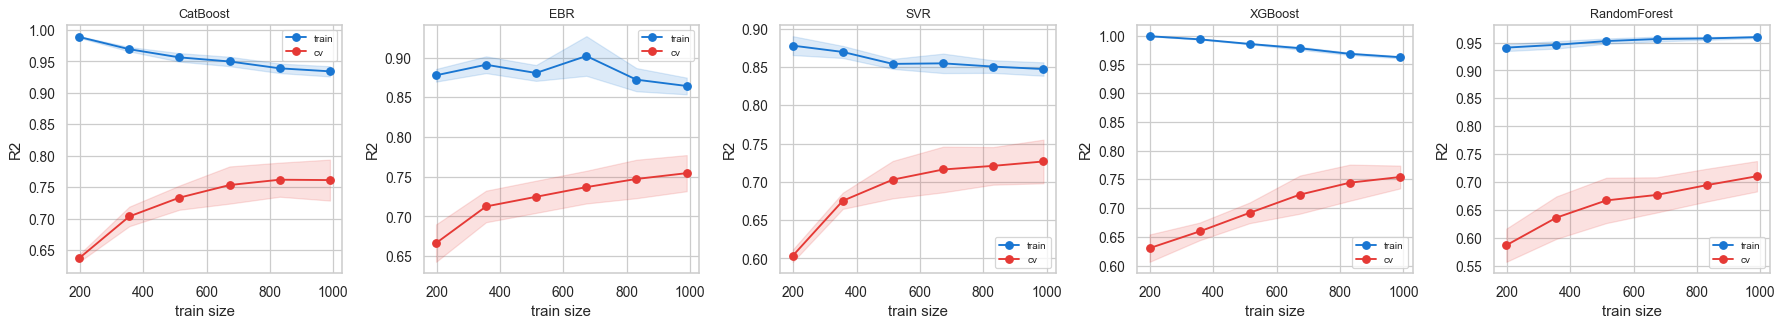

In [14]:
fig, axes = plt.subplots(1, 5, figsize=(20, 3.8))
for ax, name in zip(axes, top5_names):
    Xt, yt = (X_train, y_train)
    if name == 'GaussianProcess':
        idx = np.random.RandomState(RNG).choice(len(X_train), size=500, replace=False)
        Xt, yt = X_train.iloc[idx], y_train.iloc[idx]
    sizes, train_sc, val_sc = learning_curve(
        tuned_models[name], Xt, yt,
        train_sizes=np.linspace(0.2, 1.0, 6),
        cv=3, scoring='r2', n_jobs=-1, random_state=RNG
    )
    train_mean, val_mean = train_sc.mean(axis=1), val_sc.mean(axis=1)
    train_std, val_std = train_sc.std(axis=1), val_sc.std(axis=1)
    ax.plot(sizes, train_mean, 'o-', color='#1976d2', label='train')
    ax.fill_between(sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#1976d2')
    ax.plot(sizes, val_mean, 'o-', color='#e53935', label='cv')
    ax.fill_between(sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#e53935')
    ax.set_title(name, fontsize=10); ax.set_xlabel('train size'); ax.set_ylabel('R2')
    ax.legend(fontsize=8)
    np.savez(MODELS_DIR / f'lc_{name}.npz', sizes=sizes, train_mean=train_mean,
             train_std=train_std, val_mean=val_mean, val_std=val_std)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'learning_curves.png', dpi=110, bbox_inches='tight')
plt.show()

**Interpretare:**
- Tree ensembles overfit clar - train R2 aproape de 1, validation in jur de
  0.75-0.8. Asta-i normal - boosting-urile invata in detaliu.
- LinearReg are gap mic dar plafon scazut: underfitting, simplul model nu poate
  capta non-liniaritatea geografica.
- Cu mai multe date, validation curve continua sa urce usor la modelele tree -
  deci ar mai ajuta sa avem mai multe puncte. La LinearReg s-a aplatizat - n-o
  sa mai ajute mai multe date, doar features mai bune.


## 6. SHAP (top 3)

Top 3 pt SHAP: ['CatBoost', 'XGBoost', 'EBR']

=== CatBoost ===


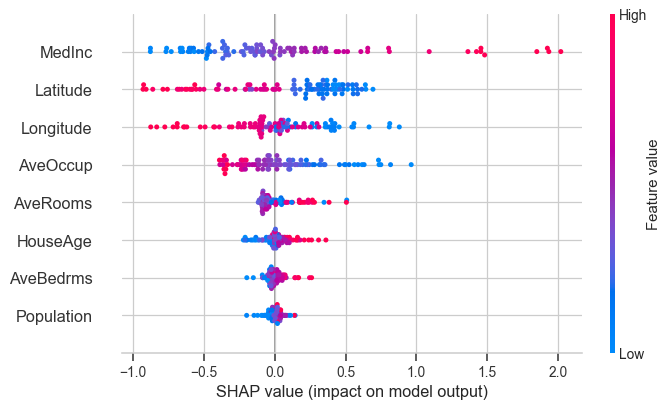

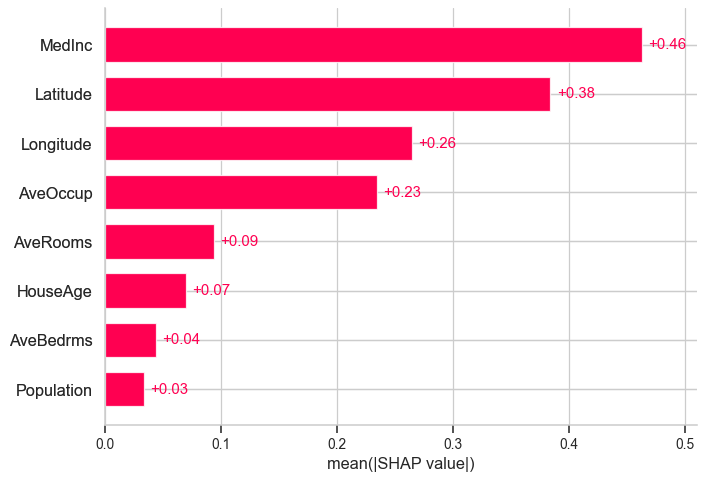

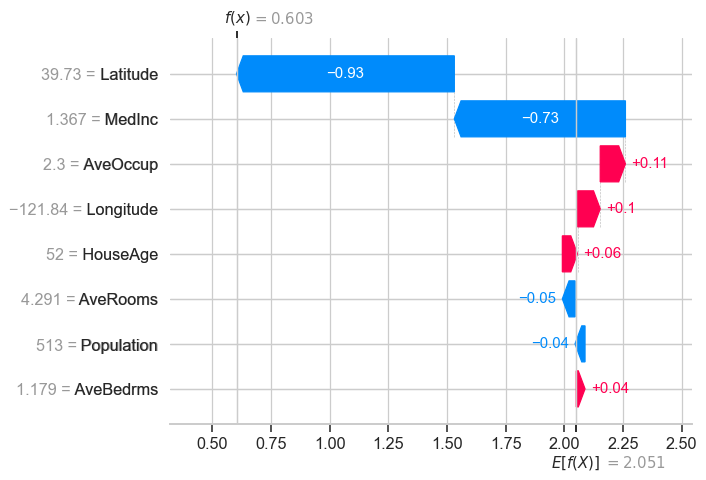

   Top 3 features: ['MedInc', 'Latitude', 'Longitude']

=== XGBoost ===


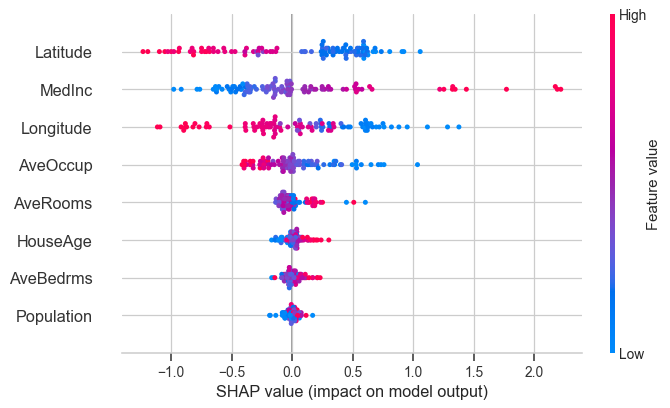

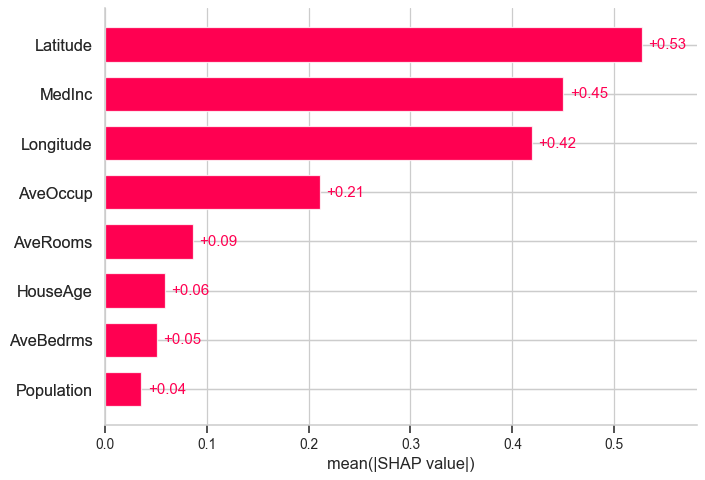

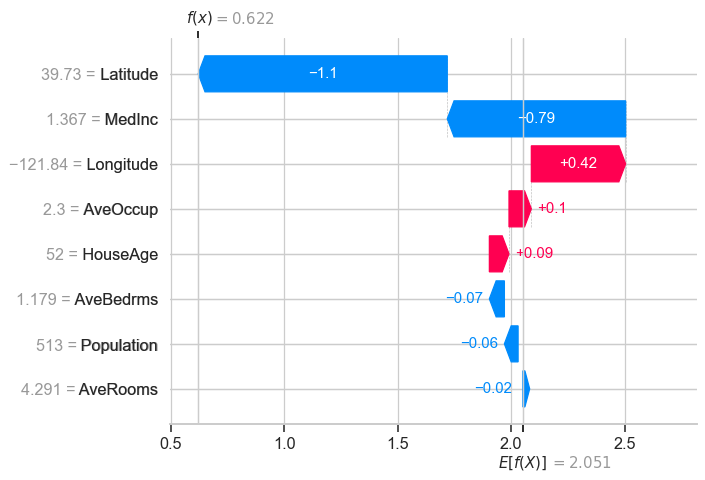

   Top 3 features: ['Latitude', 'MedInc', 'Longitude']

=== EBR ===


  0%|          | 0/50 [00:00<?, ?it/s]

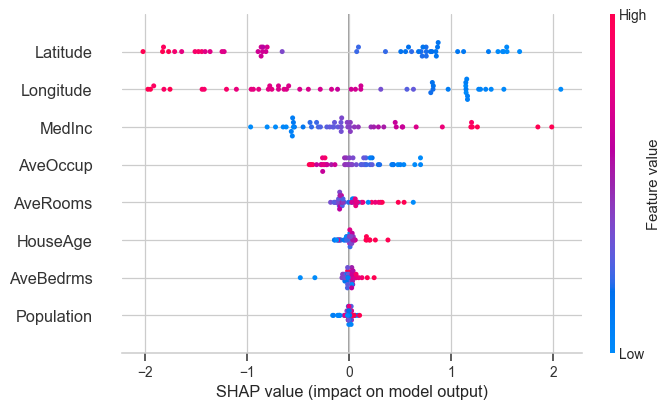

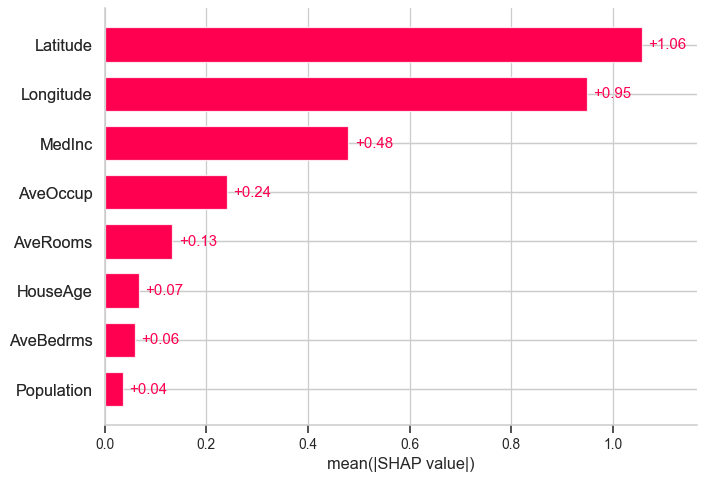

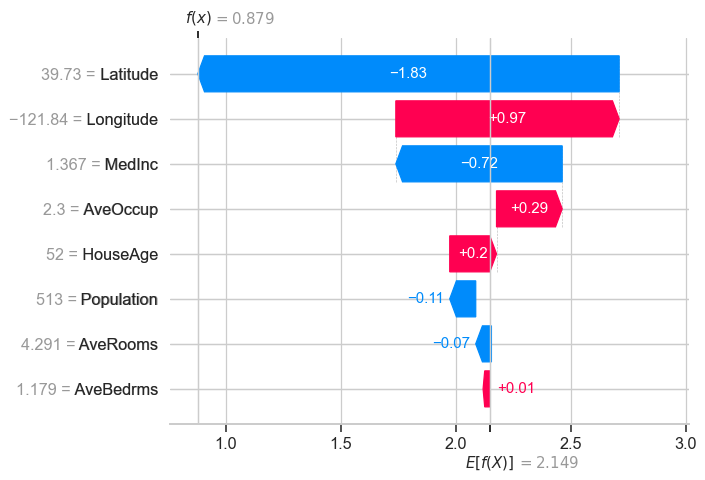

   Top 3 features: ['Latitude', 'Longitude', 'MedInc']


In [15]:
top3_names = tuned_df.head(3).index.tolist()
print('Top 3 pt SHAP:', top3_names)

bg = X_train.sample(100, random_state=RNG)
X_explain = X_test.iloc[:100].copy()

for name in top3_names:
    pipe = tuned_models[name]
    scaler = pipe.named_steps.get('scaler')
    model = pipe.named_steps['model']
    bg_t = scaler.transform(bg) if scaler else bg.values
    Xe_t = scaler.transform(X_explain) if scaler else X_explain.values

    print(f'\n=== {name} ===')
    if name in ('XGBoost', 'CatBoost', 'RandomForest', 'DecisionTree'):
        explainer = shap.TreeExplainer(model)
        sv = explainer(Xe_t)
    else:
        f = lambda x: model.predict(x)
        explainer = shap.KernelExplainer(f, bg_t)
        sv = explainer(Xe_t[:50])

    sv_obj = shap.Explanation(values=sv.values, base_values=sv.base_values,
                              data=Xe_t[:sv.values.shape[0]], feature_names=features)

    plt.figure(figsize=(8, 5))
    shap.summary_plot(sv_obj, features=Xe_t[:sv.values.shape[0]], feature_names=features, show=False)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'shap_summary_{name}.png', dpi=110, bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(7, 4))
    shap.plots.bar(sv_obj, show=False, max_display=8)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'shap_bar_{name}.png', dpi=110, bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(8, 5))
    shap.plots.waterfall(sv_obj[0], show=False, max_display=8)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'shap_waterfall_{name}.png', dpi=110, bbox_inches='tight')
    plt.show()

    if name == top3_names[0]:
        np.savez(MODELS_DIR / 'shap_data.npz',
                 values=sv.values, base_values=sv.base_values, data=Xe_t[:sv.values.shape[0]])

    mean_abs = np.abs(sv.values).mean(axis=0)
    top_feats = [features[i] for i in np.argsort(mean_abs)[::-1][:3]]
    print(f'   Top 3 features: {top_feats}')

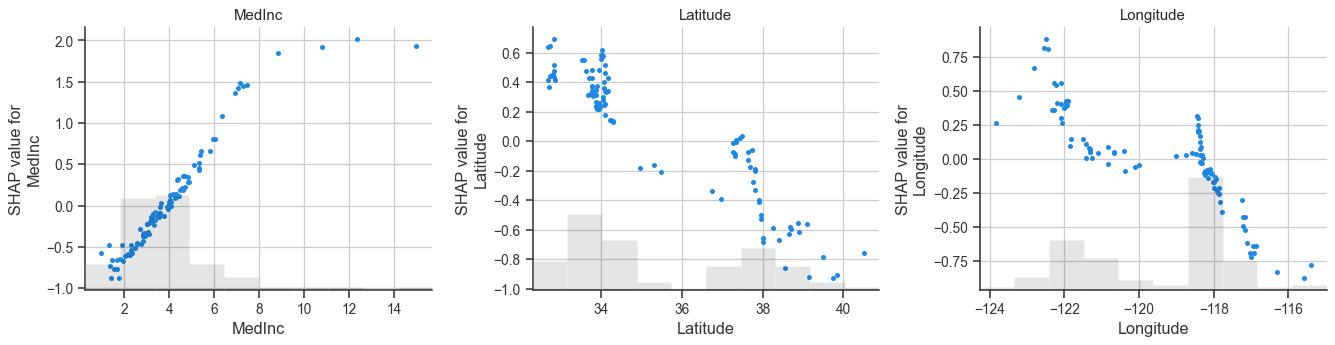

In [16]:
# scatter plots top 3 features pt cel mai bun
best_pipe = tuned_models[top3_names[0]]
scaler = best_pipe.named_steps.get('scaler')
model = best_pipe.named_steps['model']
bg_t = scaler.transform(bg) if scaler else bg.values
Xe_t = scaler.transform(X_explain) if scaler else X_explain.values

if top3_names[0] in ('XGBoost', 'CatBoost', 'RandomForest', 'DecisionTree'):
    explainer = shap.TreeExplainer(model)
    sv = explainer(Xe_t)
    sv_obj = shap.Explanation(values=sv.values, base_values=sv.base_values,
                              data=Xe_t, feature_names=features)
    mean_abs = np.abs(sv.values).mean(axis=0)
    top_idx = np.argsort(mean_abs)[::-1][:3]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, idx in zip(axes, top_idx):
        shap.plots.scatter(sv_obj[:, idx], ax=ax, show=False)
        ax.set_title(features[idx])
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'shap_scatter_top3.png', dpi=110, bbox_inches='tight')
    plt.show()

**Interpretare SHAP regresie:**
- `MedInc` e pe primul loc, fara surpriza - cartiere bogate => case scumpe.
  Valori mari de income impingere predictia in sus, valori mici in jos. Linear.
- `Latitude` si `Longitude` apar in top 3 cu pattern non-linear: anumite zone
  geografice (coasta, San Francisco / LA) ridica pretul indiferent de income.
  Asta e exact ce LinearReg nu putea prinde.
- `AveOccup` e a 4-a/5-a - cartierele cu multi locuitori per casa au preturi mai mici
  (probabil zone aglomerate, mai sarace).

**Exemplu local (waterfall pe primul cartier):** se vede cum baseline-ul (~media
target-ului) e modificat de fiecare feature in parte. Daca primul cartier avea
income mare, se aduna o contributie pozitiva mare. Daca latitude indica nordul
California departe de SF, scade.


## 7. Salvare artefacte

In [17]:
for name, mdl in tuned_models.items():
    joblib.dump(mdl, MODELS_DIR / f'model_{name}.joblib')

X_test.to_parquet(MODELS_DIR / 'X_test.parquet')
y_test.to_frame().to_parquet(MODELS_DIR / 'y_test.parquet')
X_train.to_parquet(MODELS_DIR / 'X_train.parquet')

feature_info = {}
for c in features:
    feature_info[c] = {
        'min': float(df[c].min()), 'max': float(df[c].max()),
        'mean': float(df[c].mean()), 'std': float(df[c].std()),
        'median': float(df[c].median()),
    }

meta = {
    'task': 'regression',
    'target_name': 'MedHouseVal',
    'target_unit': '$100,000',
    'features': features,
    'feature_info': feature_info,
    'top5': top5_names,
    'top3_shap': top3_names,
    'best_model': best_name,
    'baseline_results': {k: {m: float(v) for m, v in r.items()} for k, r in baseline_results.items()},
    'tuned_results': {k: {m: float(v) for m, v in r.items()} for k, r in tuned_results.items()},
    'tuned_params': {k: {kk: (float(vv) if isinstance(vv, (np.floating,)) else vv)
                         for kk, vv in v.items()} for k, v in tuned_params.items()},
    'dataset_info': {
        'name': 'California Housing (subsample 2000)',
        'n_rows': len(df), 'n_features': len(features),
    }
}
with open(MODELS_DIR / 'meta.json', 'w', encoding='utf-8') as f:
    json.dump(meta, f, indent=2, default=str)

print('Salvat:', list(MODELS_DIR.iterdir()))
print('\nGata!')

Salvat: [WindowsPath('D:/proiect-ml-jackjack242/models/reg/lc_CatBoost.npz'), WindowsPath('D:/proiect-ml-jackjack242/models/reg/lc_EBR.npz'), WindowsPath('D:/proiect-ml-jackjack242/models/reg/lc_RandomForest.npz'), WindowsPath('D:/proiect-ml-jackjack242/models/reg/lc_SVR.npz'), WindowsPath('D:/proiect-ml-jackjack242/models/reg/lc_XGBoost.npz'), WindowsPath('D:/proiect-ml-jackjack242/models/reg/meta.json'), WindowsPath('D:/proiect-ml-jackjack242/models/reg/model_CatBoost.joblib'), WindowsPath('D:/proiect-ml-jackjack242/models/reg/model_EBR.joblib'), WindowsPath('D:/proiect-ml-jackjack242/models/reg/model_RandomForest.joblib'), WindowsPath('D:/proiect-ml-jackjack242/models/reg/model_SVR.joblib'), WindowsPath('D:/proiect-ml-jackjack242/models/reg/model_XGBoost.joblib'), WindowsPath('D:/proiect-ml-jackjack242/models/reg/shap_data.npz'), WindowsPath('D:/proiect-ml-jackjack242/models/reg/X_test.parquet'), WindowsPath('D:/proiect-ml-jackjack242/models/reg/X_train.parquet'), WindowsPath('D:/pr